<a href="https://colab.research.google.com/github/Hibashanti/Prediction-Product-Sale/blob/main/Prediction%20of%20Product%20Sale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sale
- Author : Hiba Shanti

## Project overview

## 1- Import Libraries and Load the Data

*   List item
*   List item



In [ ]:
# Mount to Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 ### 1.1-Imports :
- Numpy
- Pandas
- Matplot
- Seaborn
- Massingno
- Mode from Statistics

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

1.2- Load The Dataset

In [ ]:
path="/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"

In [ ]:
df_sales=pd.read_csv(path)
df_sales

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


# 2- Inspecting The Data

In [ ]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
df_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#### 2.1- Rows and Columns
- Number of Rows
'8523'

- Number od Columns
'12'


In [ ]:
df_sales.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


### 2.2-Types of Data
- float 4
- Int    1
- object 7

## 3- Data Cleaning






- 3.1-Inspecting and Droping Duplicates

In [ ]:
df_sales.duplicated().sum()

np.int64(0)

- there is zero duplicates in the dataset

- 3.2-Inspecting Missing Values

In [ ]:
df_sales.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
#check for column type :
df_sales["Item_Weight"].dtypes

dtype('float64')

In [ ]:
# Counts different Types availabe
count_types=df_sales["Item_Type"].value_counts()
count_types


,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


In [ ]:
#calculate the mean value of weight for each item_type and fill weight mean value in its missing in Item_Weight :
mean_by_type=df_sales.groupby("Item_Type")["Item_Weight"].mean()
for item_type in mean_by_type.index :
  df_sales.loc[(df_sales["Item_Type"] == item_type) & (df_sales["Item_Weight"].isna()), "Item_Weight"] = mean_by_type[item_type]

In [ ]:
#Confirm no Missing Values in Item_weight
df_sales["Item_Weight"].isna().sum()

np.int64(0)

In [ ]:
#check Type for Outlet_Size column
df_sales["Outlet_Size"].dtypes

dtype('O')

In [ ]:
df_sales["Outlet_Size"].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [ ]:
df_sales["Outlet_Size"]=df_sales["Outlet_Size"].fillna("MISSING")
df_sales["Outlet_Size"]

,Outlet_Size
0,Medium
1,Medium
2,Medium
3,MISSING
4,High
...,...
8518,High
8519,MISSING
8520,Small
8521,Medium


In [ ]:
df_sales["Outlet_Size"].value_counts()

,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
High,932


In [ ]:
df_sales.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


- Inspect Inconsistanses
  - 1- Catagorical Values
  - 2- Numerical Values

In [ ]:
# Display categorical columns
cat_col=df_sales.select_dtypes("object").columns
cat_col

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [ ]:
#to check for inconsistances in each category:
for col in cat_col :
  print(f"Value Counts for {col}")
  print(df_sales[col].value_counts())
  print('\n')

Value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [ ]:
df_sales["Item_Fat_Content"]=df_sales["Item_Fat_Content"].replace({"LF":"Low Fat", "low fat":"Low Fat", "reg" : "Regular"})
df_sales["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


- Summary Statistics for numerical Data

In [ ]:
# Display numeriacl columns
num_col=df_sales.select_dtypes("number").columns
num_col

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
#The summury statistics for the numerical values
df_sales[num_col].describe()


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857890,0.066132,140.992782,1997.831867,2181.288914
std,4.232804,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.867061,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## 4-Data Visualizayion

In [ ]:
df_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,MISSING,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


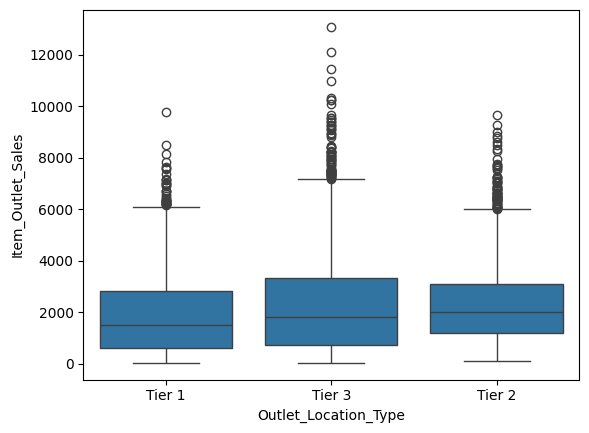

In [ ]:
# Display the relation between Outlet_Location_Type and Item_Outlet_Salesusing Boxplots
sns.boxplot(data=df_sales, x='Outlet_Location_Type', y="Item_Outlet_Sales");

In [ ]:
# Visualize the relation between Item_type and Item_Visibility
#grouping the values
visual=df_sales.groupby("Item_Type")["Item_Visibility"].mean()
visual

,Item_Visibility
Item_Type,
Baking Goods,0.069169
Breads,0.066255
Breakfast,0.085723
Canned,0.068129
Dairy,0.072427
Frozen Foods,0.065645
Fruits and Vegetables,0.068513
Hard Drinks,0.064943
Health and Hygiene,0.055216


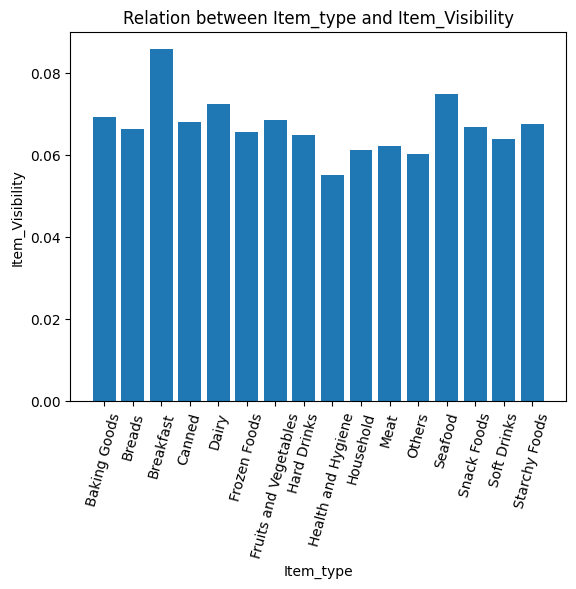

In [ ]:
# Drow the Barplot to visualize the relation between Item_type and Item_Visibility
fig, ax=plt.subplots()
ax.bar(visual.index,visual.values)
ax.tick_params(axis='x', rotation=75)
ax.set_title("Relation between Item_type and Item_Visibility")
ax.set_xlabel("Item_type")
ax.set_ylabel("Item_Visibility");

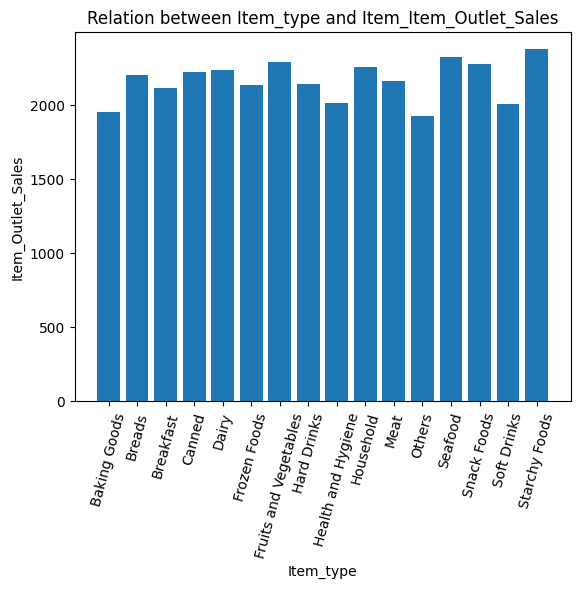

In [ ]:
#Relation between Item_Type and Item_Outlet_Sales
Type_MRP=df_sales.groupby("Item_Type")["Item_Outlet_Sales"].mean()
# drow the plot
fig, ax=plt.subplots()
ax.bar(Type_MRP.index,Type_MRP.values)
ax.tick_params(axis='x', rotation=75)
ax.set_title("Relation between Item_type and Item_Item_Outlet_Sales")
ax.set_xlabel("Item_type")
ax.set_ylabel("Item_Outlet_Sales");

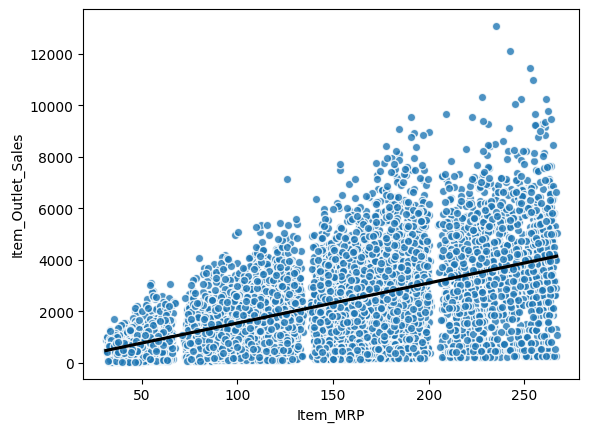

In [ ]:
#Display the Relation between Item_MRP and Item_Outlet_Sales
line_kws=dict(color="black")
scatter_kws=dict(edgecolor="White")
sns.regplot(data=df_sales, x='Item_MRP', y='Item_Outlet_Sales',line_kws=line_kws, scatter_kws=scatter_kws);


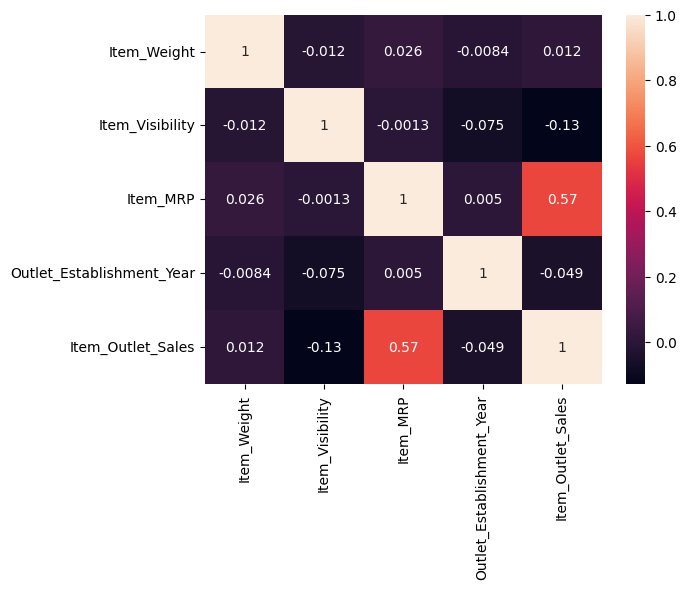

In [ ]:
# Correlation between all numerical data using Heatmap
corr_relationship=df_sales.corr(numeric_only=True)
sns.heatmap(corr_relationship, color="Blue", annot=True);